In [1]:
import re
import os
import glob
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from adjustText import adjust_text
from collections import Counter, defaultdict
from Bio import SeqIO, Seq, SeqRecord

In [2]:
# plot appearance default parameters
mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family="Helvetica", size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=8)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

In [3]:
#functions
def has_target_gene(gene_string, target_genes):
    """Check if any gene in a comma-separated gene string is in target_genes."""
    if pd.isna(gene_string):
        return False
    genes = [g.strip() for g in str(gene_string).split(',')]
    return any(g in target_genes for g in genes)

def get_enhancer_records(df, gene, divide_by=None):
    """
    Get enhancer records for a single gene, optionally split into two groups.
    Returns
    If divide_by is None: DataFrame
    If divide_by is dict: (matching_df, non_matching_df)
    """
    gene_mask = df['gene'].apply(has_target_gene, target_genes={gene})
    new_df = df[gene_mask]

    if divide_by is not None:
        match_mask = pd.Series(True, index=new_df.index)
        for col, val in divide_by.items():
            match_mask &= (new_df[col] == val)

        cat_df = new_df[match_mask]
        non_cat_df = new_df[~match_mask]
        return cat_df, non_cat_df
    else:
        return new_df

def get_bed(df):
    """Return list of BED lines (chr, start, stop) for writing."""
    return (
        df['chr'].astype(str) + '\t' + 
        df['start'].astype(str) + '\t' + 
        df['stop'].astype(str)
    ).tolist()


def get_fasta(df):
    """
    Return list of SeqRecord objects for each enhancer,
    extracting only the hg38 reference sequence from each per-enhancer file.
    """
    fasta_path = '../output/1_2_FASTA_per_enh'
    records = []

    for enhancer_id, row in df.iterrows():
        file = os.path.join(fasta_path, enhancer_id + '.fa')

        if not os.path.exists(file):
            print(f'WARNING: FASTA file not found for {enhancer_id}, skipping.')
            continue

        for record in SeqIO.parse(file, 'fasta'):
            if 'hg38' in record.id:
                record.id = enhancer_id
                record.description = ''
                record.seq = record.seq.upper()
                records.append(record)
                break

    return records

In [ ]:
# inputs
adata = ad.read_h5ad('../data/Enhancers_AnnData.h5ad')

In [54]:
#  get all genes linked to primate-specific enhancers
gene_list_PS = adata.var.loc[
    adata.var['category'] == 'primate_specific', 'gene'
].dropna().tolist()

target_genes = set()
for genes in gene_list_PS:
    for g in str(genes).split(','):
        g = g.strip()
        if g:
            target_genes.add(g)

### 1 - Preparing data for MEME AME (run only once)

In [ ]:
# keep enhancers linked to at least one target gene
enh_mask = adata.var['gene'].apply(has_target_gene)
adata_sub = adata[:, enh_mask].copy()
all_enhs = adata_sub.var

In [50]:
output_dir = '../output/5_2_Files_for_motif_enrichment'
os.makedirs(output_dir, exist_ok=True)

for gene in target_genes:
    gene_dir = f'{output_dir}/{gene}'
    os.makedirs(gene_dir, exist_ok=True)

    PS_df, NPS_df = get_enhancer_records(all_enhs, gene, divide_by={'category': 'primate_specific'})

    # BED files
    PS_bed  = get_bed(PS_df)
    NPS_bed = get_bed(NPS_df)

    with open(f'{gene_dir}/PS_coord.bed', 'w') as f:
        f.write('\n'.join(PS_bed) + '\n')
    with open(f'{gene_dir}/NPS_coord.bed', 'w') as f:
        f.write('\n'.join(NPS_bed) + '\n')

    # FASTA files — SeqIO.write handles SeqRecord objects directly
    PS_fasta  = get_fasta(PS_df)
    NPS_fasta = get_fasta(NPS_df)

    SeqIO.write(PS_fasta,  f'{gene_dir}/PS_sequences.fasta',  'fasta')
    SeqIO.write(NPS_fasta, f'{gene_dir}/NPS_sequences.fasta', 'fasta')

In [43]:
with open('../data/5_2_target_genes.txt', 'w') as f:
    for g in target_genes:
        f.write(f'{g}\n')

MEME AME was run with a set of scripts which can be found in ../scripts directory

### 2 - Processing results from AME

In [ ]:
ctrl_df = pd.read_csv('../output/5_3A_Global_motif_enrichment/control/ame.tsv', sep='\t', header=0, 
                      comment='#', index_col=0)

,motif_DB,motif_ID,motif_alt_ID,consensus,p-value,adj_p-value,E-value,tests,FASTA_max,pos,neg,PWM_min,TP,%TP,FP,%FP
rank,,,,,,,,,,,,,,,,
1,../data/5_HOCOMOCO_motifs_db_v5.meme,ZN770.H14CORE.1.P.B,NaN,GGAGGCYGRGGBRGGAGGAKSR,1.060000e-21,3.570000e-19,5.690000e-16,338,84,84,1008,20.80,31,36.90,28,2.78
2,../data/5_HOCOMOCO_motifs_db_v5.meme,ZBT17.H14CORE.0.P.B,NaN,VGGHGGGGGMGGGGVDSV,3.910000e-19,2.670000e-16,4.250000e-13,682,84,84,1008,7.58,40,47.62,81,8.04
3,../data/5_HOCOMOCO_motifs_db_v5.meme,ZN281.H14CORE.1.SM.B,NaN,KGGGGGGGGGGGGGGAGGGDRGGKKK,8.410000e-17,2.750000e-14,4.390000e-11,327,84,84,1008,1.43,57,67.86,230,22.82
4,../data/5_HOCOMOCO_motifs_db_v5.meme,KLF14.H14CORE.1.P.C,NaN,VDGKGGGCGKGGCYGGGRGDGGG,9.360000e-17,4.910000e-14,7.820000e-11,524,84,84,1008,2.42,60,71.43,260,25.79
5,../data/5_HOCOMOCO_motifs_db_v5.meme,KLF16.H14CORE.1.P.B,NaN,GSGGGRGGRGGCGGGGCNGGRGG,1.220000e-16,5.280000e-14,8.420000e-11,432,84,84,1008,2.42,57,67.86,232,23.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,../data/5_HOCOMOCO_motifs_db_v5.meme,BHE40.H14CORE.1.S.C,NaN,NDCACGTGNNNRKCACGTGMNN,1.980000e-04,5.130000e-03,8.180000e+00,26,84,84,1008,1.63,7,8.33,11,1.09
202,../data/5_HOCOMOCO_motifs_db_v5.meme,ZN878.H14CORE.0.PS.A,NaN,ACANRRCAGGACAAAAAWW,2.700000e-05,5.240000e-03,8.360000e+00,195,84,84,1008,2.77,20,23.81,81,8.04
203,../data/5_HOCOMOCO_motifs_db_v5.meme,PO3F1.H14CORE.0.P.B,NaN,DYATGCAWATKMADN,1.850000e-05,5.710000e-03,9.110000e+00,309,84,84,1008,2.44,25,29.76,117,11.61


In [ ]:
ctrl_df['motif_alt_ID'] = ctrl_df['motif_ID'].str.split('.').str[0]
ctrl_df['%diff_abs'] = (ctrl_df['%TP'] - ctrl_df['%FP']).abs() #delta between query and background
ctrl_df

/tmp/ipykernel_3433672/605285020.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=top['motif_alt_ID'], rotation=45)


[Text(0, 0, 'KLF14'),
 Text(1, 0, 'ZN281'),
 Text(2, 0, 'KLF16'),
 Text(3, 0, 'KLF13'),
 Text(4, 0, 'LYL1'),
 Text(5, 0, 'KLF15'),
 Text(6, 0, 'MAZ'),
 Text(7, 0, 'SP5'),
 Text(8, 0, 'SP4'),
 Text(9, 0, 'VEZF1'),
 Text(10, 0, 'SP2'),
 Text(11, 0, 'ZN613'),
 Text(12, 0, 'ZBT17'),
 Text(13, 0, 'SALL1'),
 Text(14, 0, 'ETV7'),
 Text(15, 0, 'ELYS'),
 Text(16, 0, 'ZNF48'),
 Text(17, 0, 'KLF8'),
 Text(18, 0, 'ZN148'),
 Text(19, 0, 'CPEB1'),
 Text(20, 0, 'ZN467'),
 Text(21, 0, 'PATZ1'),
 Text(22, 0, 'KLF10'),
 Text(23, 0, 'KLF17'),
 Text(24, 0, 'MAZ'),
 Text(25, 0, 'LYL1'),
 Text(26, 0, 'ZN770'),
 Text(27, 0, 'KLF6'),
 Text(28, 0, 'SP2'),
 Text(29, 0, 'KLF7'),
 Text(30, 0, 'STAT1'),
 Text(31, 0, 'ZN383'),
 Text(32, 0, 'IRF4'),
 Text(33, 0, 'SALL4'),
 Text(34, 0, 'PATZ1'),
 Text(35, 0, 'MYOD1'),
 Text(36, 0, 'ZN770'),
 Text(37, 0, 'ERF'),
 Text(38, 0, 'ZN282'),
 Text(39, 0, 'STAT2'),
 Text(40, 0, 'PRDM6'),
 Text(41, 0, 'SP5'),
 Text(42, 0, 'FLI1'),
 Text(43, 0, 'WT1')]

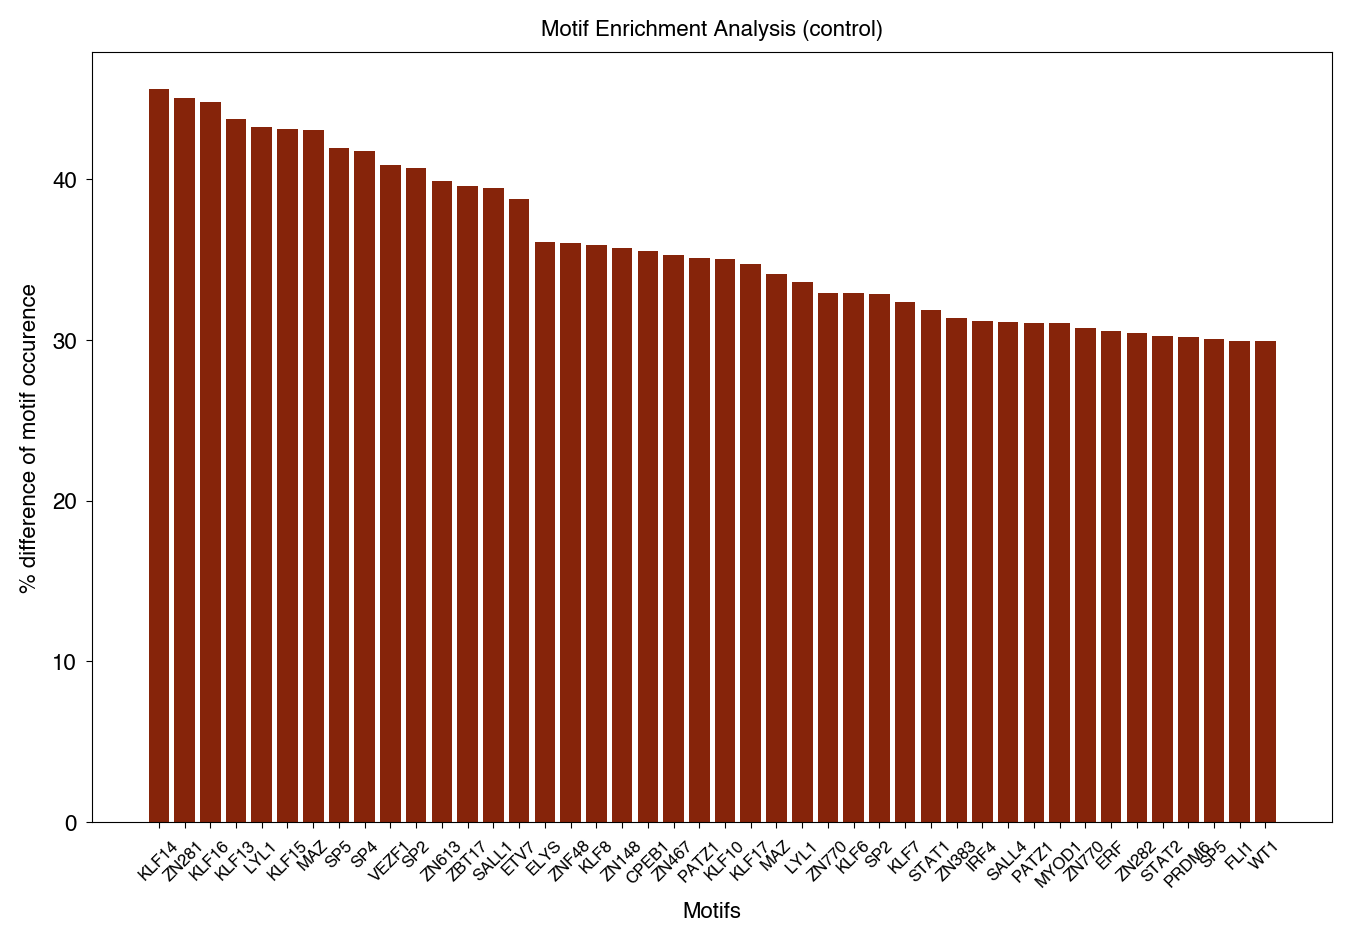

In [37]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=200)

custom_div = mpl.colors.LinearSegmentedColormap.from_list(
"custom_div",
["#6E7688", "#86240A"]
)

top = ctrl_df.nlargest(50, '%diff_abs')

#plot
ax.bar(top['motif_alt_ID'], top['%diff_abs'].to_numpy(), color='#86240A')

# labels
ax.set_title('Motif Enrichment Analysis (control)')
ax.set_xlabel('Motifs')
ax.set_ylabel('% difference of motif occurence')

ax.set_xticklabels(labels=top['motif_alt_ID'], rotation=45)

In [38]:
for i, row in top.iterrows():
    print(f"{row['motif_alt_ID']}")

KLF14
ZN281
KLF16
KLF13
LYL1
KLF15
MAZ
SP5
SP4
VEZF1
SP2
ZN613
ZBT17
SALL1
ETV7
ELYS
ZNF48
KLF8
ZN148
CPEB1
ZN467
PATZ1
KLF10
KLF17
MAZ
LYL1
ZN770
KLF6
SP2
KLF7
STAT1
ZN383
IRF4
SALL4
PATZ1
MYOD1
ZN770
ERF
ZN282
STAT2
PRDM6
SP5
FLI1
WT1
ATOH8
ZN681
NFAC3
PTF1A
TAL1
GLYR1
